In [1]:
import polars as pl 
import seaborn as sns 
import matplotlib.pyplot as plt 
from dbconfig import engine 
print("Environment ready!")

Environment ready!


In [2]:
base_table = pl.read_database(
        query="""
        with match_stats as (
            select season, team,
            count(distinct id) as matches_played,
            sum(is_win) as wins
            from (
                select team1 as team,
                id, season,
                case when winner = team1 then 1 else 0 end as
  is_win
                from matches

                union all

                select team2 as team,
                id, season,
                case when winner = team2 then 1 else 0 end as
  is_win
                from matches
            ) as stacked
            group by season, team
        ),

        batting_stats as (
            select
            batting_team as team,
            season,
            count(*) as balls_faced,
            count(*) filter(where total_runs = 0) as dot_balls,
            count(*) filter(where batsman_runs in (4,6)) as
  boundaries,
            sum(total_runs) as runs_scored
            from ipl_master_view
            where inning in (1,2)
            group by team, season
        ),

        bowling_stats as (
            select
            bowling_team as team,
            season,
            count(*) as balls_faced,
            count(*) filter(where total_runs = 0) as dot_balls,
            count(*) filter(where batsman_runs in (4,6)) as
  boundaries,
            sum(total_runs) as runs_scored
            from ipl_master_view
            where inning in (1,2)
            group by team, season
        )

        select
            m.team,
            m.season,
            m.matches_played,
            round(100.00 * m.wins::numeric / m.matches_played, 2)
  as win_pct,
            -- Batting metrics
            round(100.00 * bat.dot_balls::numeric / bat.
  balls_faced, 2) as bat_dot_ball_pct,
            round(100.00 * bat.boundaries::numeric / bat.
  balls_faced, 2) as bat_boundary_pct,
            round(bat.runs_scored::numeric / bat.balls_faced * 6.00, 2) as bat_run_rate,
            -- Bowling metrics
            round(100.00 * bowl.dot_balls::numeric / bowl.
  balls_faced, 2) as bowl_dot_ball_pct,
            round(100.00 * bowl.boundaries::numeric / bowl.
  balls_faced, 2) as bowl_boundary_pct,
            round(bowl.runs_scored::numeric / bowl.balls_faced * 6.00, 2) as bowl_run_rate
        from match_stats m
        join batting_stats bat on m.team = bat.team and m.season =
  bat.season
        join bowling_stats bowl on m.team = bowl.team and m.season
  = bowl.season
        order by m.team, m.season;
        """,
        connection=engine
    )

In [5]:
base_table.head(5)

team,season,matches_played,win_pct,bat_dot_ball_pct,bat_boundary_pct,bat_run_rate,bowl_dot_ball_pct,bowl_boundary_pct,bowl_run_rate
str,str,i64,"decimal[38,2]","decimal[38,2]","decimal[38,2]","decimal[38,2]","decimal[38,2]","decimal[38,2]","decimal[38,2]"
"""Chennai Super Kings""","""2007/08""",16,56.25,36.18,17.61,8.07,34.22,16.82,8.08
"""Chennai Super Kings""","""2009""",14,57.14,34.41,15.51,7.83,37.70,14.58,7.39
"""Chennai Super Kings""","""2009/10""",16,56.25,33.50,15.88,8.00,36.90,15.63,7.64
"""Chennai Super Kings""","""2011""",16,68.75,32.61,15.15,7.89,35.81,13.98,7.36
"""Chennai Super Kings""","""2012""",18,55.56,34.49,14.89,7.78,34.85,14.54,7.45


In [3]:
batting_dot_median = base_table['bat_dot_ball_pct'].median()
batting_boundary_median = base_table['bat_boundary_pct'].median()
print(f"batting_dot_median : {batting_dot_median} \nbatting_boundary_median : {batting_boundary_median}")

batting_dot_median : 34.595 
batting_boundary_median : 16.27


In [4]:
bowling_dot_median = base_table['bowl_dot_ball_pct'].median()
bowling_boundary_median = base_table['bowl_boundary_pct'].median()
print(f"bowling_dot_median : {bowling_dot_median} \nbowling_boundary_median : {bowling_boundary_median}")

bowling_dot_median : 34.75 
bowling_boundary_median : 16.575


In [5]:
bad_batting = (pl.col("bat_dot_ball_pct") >= batting_dot_median) & (pl.col("bat_boundary_pct") < batting_boundary_median)
bad_bowling = (pl.col("bowl_dot_ball_pct") < bowling_dot_median) & (pl.col("bowl_boundary_pct") >= bowling_boundary_median)

In [6]:
quadrant_df = base_table.with_columns(
        pl.when(bad_batting & bad_bowling).
  then(pl.lit("Poor Batting, Poor Bowling"))
        .when(~bad_batting & bad_bowling).
  then(pl.lit("Good Batting, Poor Bowling"))
        .when(bad_batting & ~bad_bowling).
  then(pl.lit("Poor Batting, Good Bowling"))
        .otherwise(pl.lit("Good Batting, Good Bowling"))
        .alias("quadrant"))

In [20]:
quadrant_df.head(5)

team,season,matches_played,win_pct,bat_dot_ball_pct,bat_boundary_pct,bat_run_rate,bowl_dot_ball_pct,bowl_boundary_pct,bowl_run_rate,quadrant
str,str,i64,"decimal[38,2]","decimal[38,2]","decimal[38,2]","decimal[38,2]","decimal[38,2]","decimal[38,2]","decimal[38,2]",str
"""Chennai Super Kings""","""2007/08""",16,56.25,36.18,17.61,8.07,34.22,16.82,8.08,"""Good Batting, Poor Bowling"""
"""Chennai Super Kings""","""2009""",14,57.14,34.41,15.51,7.83,37.70,14.58,7.39,"""Good Batting, Good Bowling"""
"""Chennai Super Kings""","""2009/10""",16,56.25,33.50,15.88,8.00,36.90,15.63,7.64,"""Good Batting, Good Bowling"""
"""Chennai Super Kings""","""2011""",16,68.75,32.61,15.15,7.89,35.81,13.98,7.36,"""Good Batting, Good Bowling"""
"""Chennai Super Kings""","""2012""",18,55.56,34.49,14.89,7.78,34.85,14.54,7.45,"""Good Batting, Good Bowling"""


In [7]:
quadrant_summary = (
        quadrant_df.group_by('quadrant').agg(
            [pl.len().alias('team_seasons'),
             pl.col('win_pct').mean().round(2).alias('avg_win_pct'),
             pl.col('win_pct').median().round(2).alias('med_win_pct')])
            .sort('avg_win_pct', descending=True))
quadrant_summary

quadrant,team_seasons,avg_win_pct,med_win_pct
str,u32,f64,f64
"""Good Batting, Good Bowling""",58,55.76,56.25
"""Good Batting, Poor Bowling""",47,45.95,46.67
"""Poor Batting, Good Bowling""",38,44.78,46.41
"""Poor Batting, Poor Bowling""",3,23.81,21.43


In [25]:
quadrant_df.filter(
    pl.col("quadrant") == "Poor Batting, Poor Bowling"
).select(
    "team",
    "season",
    "win_pct",
    "quadrant"
)

team,season,win_pct,quadrant
str,str,"decimal[38,2]",str
"""Delhi Capitals""","""2014""",14.29,"""Poor Batting, Poor Bowling"""
"""Delhi Capitals""","""2023""",35.71,"""Poor Batting, Poor Bowling"""
"""Punjab Kings""","""2015""",21.43,"""Poor Batting, Poor Bowling"""


In [8]:
gg = quadrant_df.filter(pl.col("quadrant") == "Good Batting, Good Bowling")["win_pct"].cast(pl.Float64).to_list()
gp = quadrant_df.filter(pl.col("quadrant") == "Good Batting, Poor Bowling")["win_pct"].cast(pl.Float64).to_list()
pg = quadrant_df.filter(pl.col("quadrant") == "Poor Batting, Good Bowling")["win_pct"].cast(pl.Float64).to_list()
pp = quadrant_df.filter(pl.col("quadrant") == "Poor Batting, Poor Bowling")["win_pct"].cast(pl.Float64).to_list()

In [9]:
from scipy.stats import kruskal

res = kruskal(gg, gp, pg, pp)

In [10]:
print(f"statistic = {res.statistic:.4f}")
print(f"pvalue = {res.pvalue:.4f}")

statistic = 27.3245
pvalue = 0.0000


In [11]:
import scikit_posthocs as sp

In [12]:
quadrant_pd = quadrant_df.to_pandas()

In [13]:
sp.posthoc_dunn(
    quadrant_pd,
    val_col="win_pct",
    group_col="quadrant",
    p_adjust="holm")

,"Good Batting, Good Bowling","Good Batting, Poor Bowling","Poor Batting, Good Bowling","Poor Batting, Poor Bowling"
"Good Batting, Good Bowling",1.000000,0.000601,0.000980,0.003109
"Good Batting, Poor Bowling",0.000601,1.000000,0.949768,0.118340
"Poor Batting, Good Bowling",0.000980,0.949768,1.000000,0.118340
"Poor Batting, Poor Bowling",0.003109,0.118340,0.118340,1.000000


In [14]:
heatmap_df = (
    quadrant_summary
    .with_columns(
        batting=pl.col("quadrant").str.extract(r"^(Good|Poor) Batting"),
        bowling=pl.col("quadrant").str.extract(r"(Good|Poor) Bowling$")
    )
    .pivot(
        on="batting",
        index="bowling",
        values="avg_win_pct"
    )
)

In [15]:
heatmap_pd = (
    heatmap_df
    .to_pandas()
    .set_index("bowling")
)

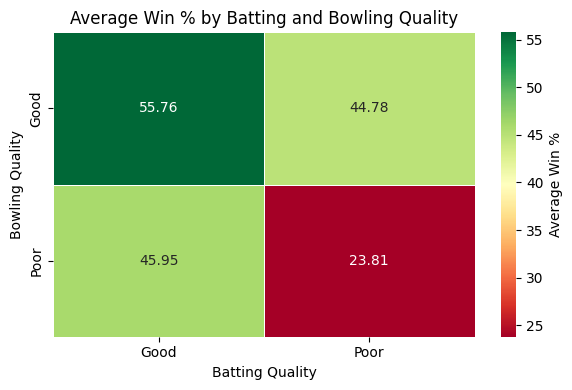

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    heatmap_pd,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5,
    cbar_kws={"label": "Average Win %"}
)

plt.title("Average Win % by Batting and Bowling Quality")
plt.xlabel("Batting Quality")
plt.ylabel("Bowling Quality")

plt.tight_layout()
plt.savefig(
    "plots/batting_bowling_interaction_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [17]:
heatmap_df.write_database(
        'batting_quality_bowling_quality_heatmap',
        connection = engine,
        if_table_exists = 'replace'
        )

2